#**Module 16 Assignment : People Flow Detection**

#**Project : People Flow Detection using Object Tracking & Heatmap Visualization**

#**Prepared by: Farjana Ferdausi**

###**This notebook implements a complete people flow detection system. It detects people using YOLOv8, tracks them with ByteTrack, counts entries/exits across two virtual lines, and generates a motion heatmap.**


#**Step:1 - Install Dependencies**

In [1]:
!pip install ultralytics opencv-python-headless numpy matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.7 MB/s eta 0:00:00


#**Step:2 – Import Libraries**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


#**Step:3 - Mount Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#**Step:4 - Configuration Dictionary**

In [4]:
CONFIG = {
    "video_url": "https://media.roboflow.com/supervision/video-examples/people-walking.mp4",
    "video_name": "people-walking.mp4",
    "output_video": "output_people_flow.mp4",
    "line_in_y": 250,
    "line_out_y": 450,
    "conf_threshold": 0.5,
    "frame_skip": 1
}

print("Configuration Dictionary Loaded:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

Configuration Dictionary Loaded:
   video_url: https://media.roboflow.com/supervision/video-examples/people-walking.mp4
   video_name: people-walking.mp4
   output_video: output_people_flow.mp4
   line_in_y: 250
   line_out_y: 450
   conf_threshold: 0.5
   frame_skip: 1


#**Step:5 - Download Input Video**

In [5]:
import requests

url = CONFIG['video_url']
print("Downloading video, please wait...")

response = requests.get(url, stream=True)
with open(CONFIG['video_name'], 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Input video ({CONFIG['video_name']}) successfully downloaded!")

Input video (people-walking.mp4) successfully downloaded!


#**Step:6 – Load Model & Initialize Variables**

In [6]:
# Load YOLOv8 model with ByteTrack support
model = YOLO('yolov8n.pt')

# Open video capture
cap = cv2.VideoCapture(CONFIG['video_name'])
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Adjust FPS for frame_skip to maintain correct video speed
output_fps = fps / CONFIG['frame_skip'] if CONFIG['frame_skip'] > 1 else fps

# Output video writer
out = cv2.VideoWriter(
    CONFIG['output_video'],
    cv2.VideoWriter_fourcc(*'mp4v'),
    output_fps,
    (frame_width, frame_height)
)

# Counter variables
in_count = 0
out_count = 0

# Dictionary to store previous Y positions for each Track ID
previous_positions = {}

# Sets to prevent double counting
crossed_in = set()
crossed_out = set()

# Heatmap accumulator array
heatmap = np.zeros((frame_height, frame_width), dtype=np.float32)

print(f"Video Size: {frame_width}x{frame_height}, FPS: {fps}")
print(f"Output Video FPS: {output_fps:.2f}")
print("Processing started...")

Video Size: 1920x1080, FPS: 25
Output Video FPS: 25.00
Processing started...


#**Step:7 – Main Processing Loop**

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 350ms
Prepared 1 package in 61ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



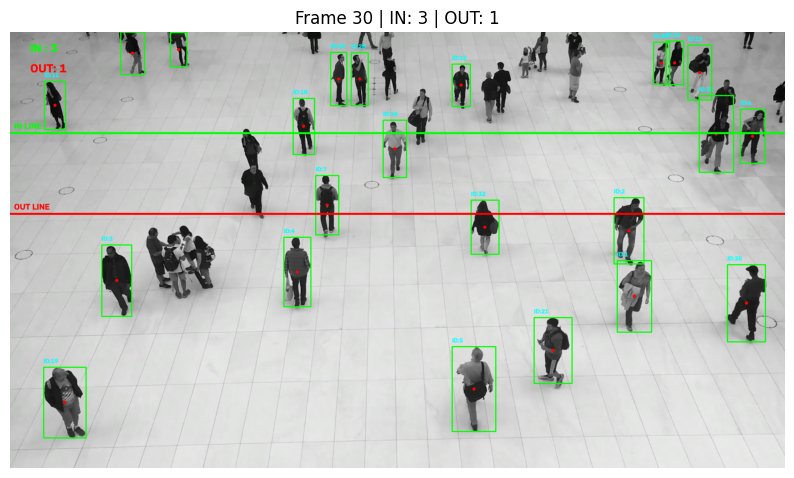

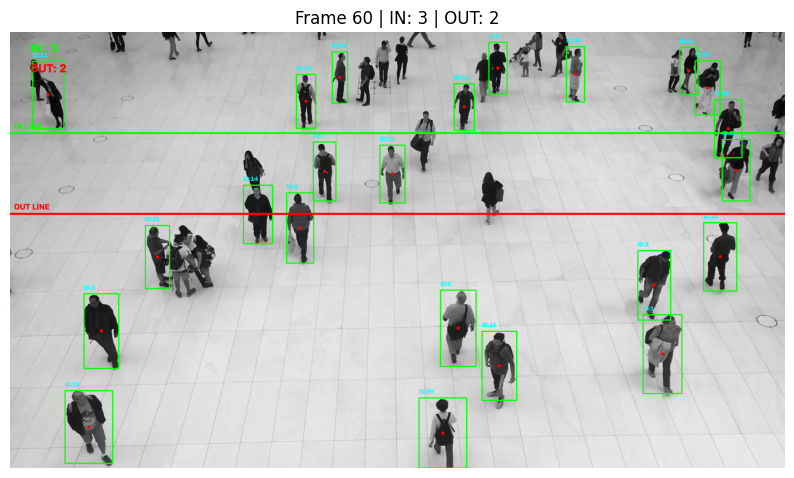

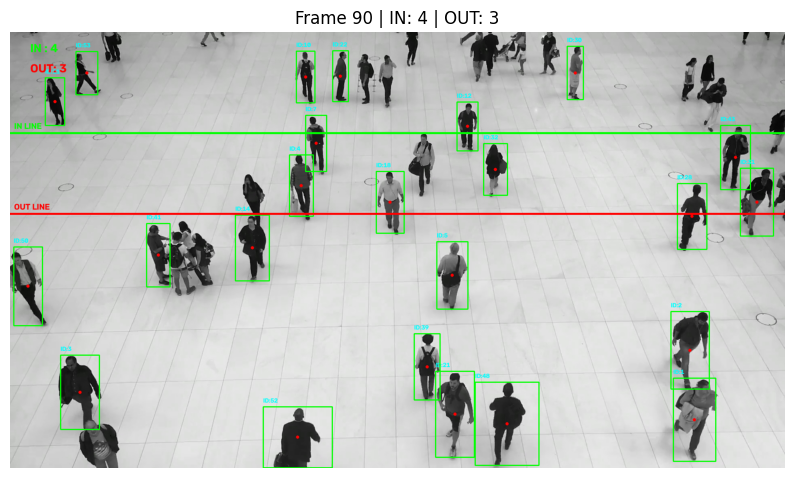

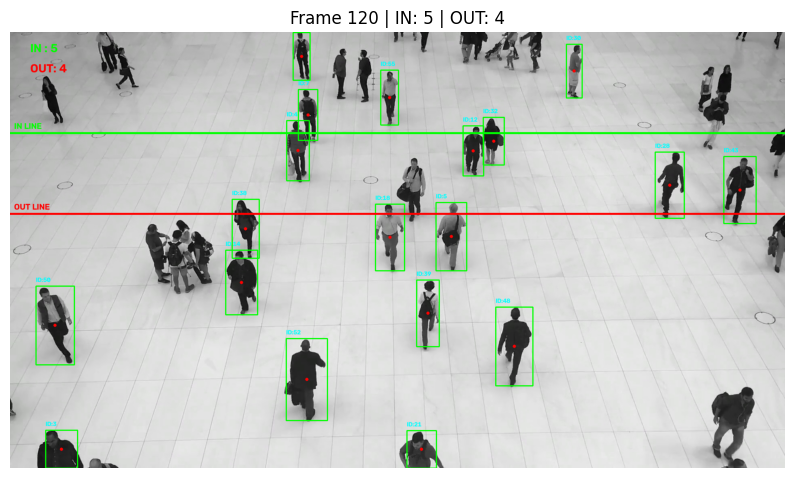

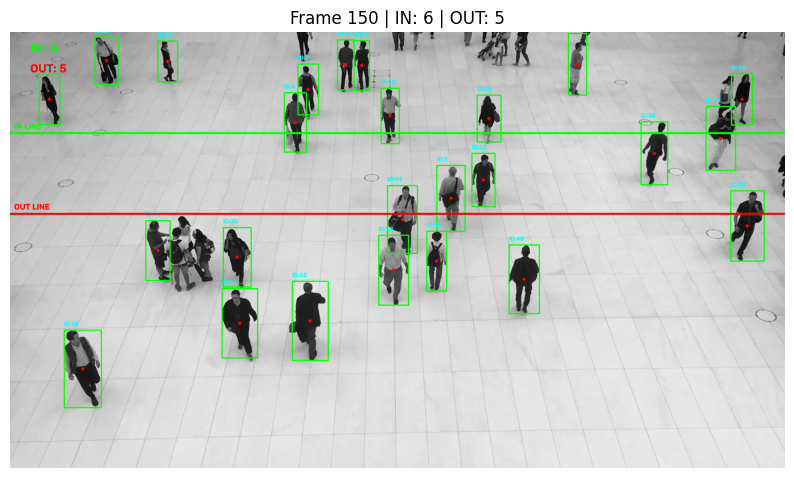

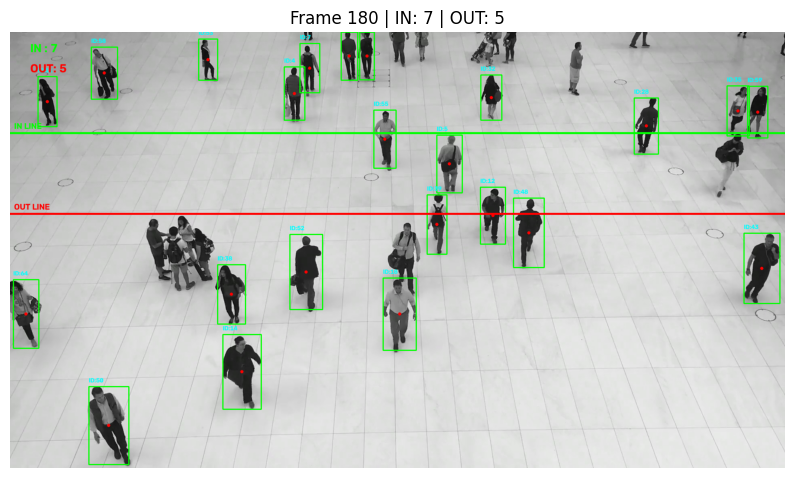

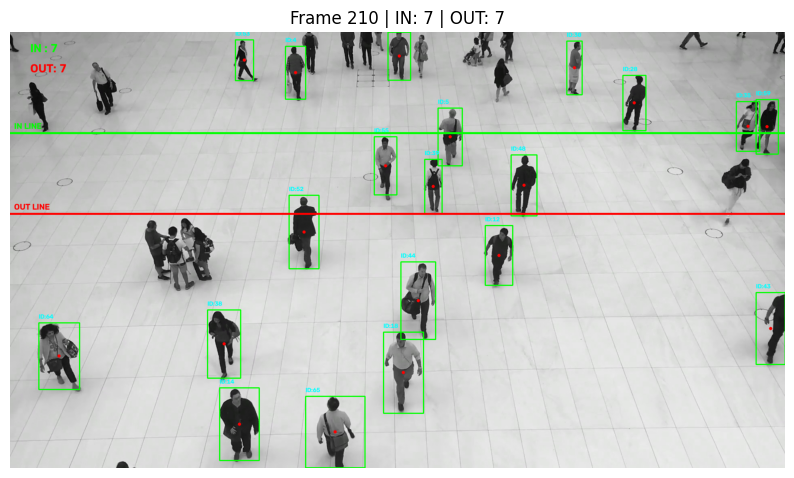

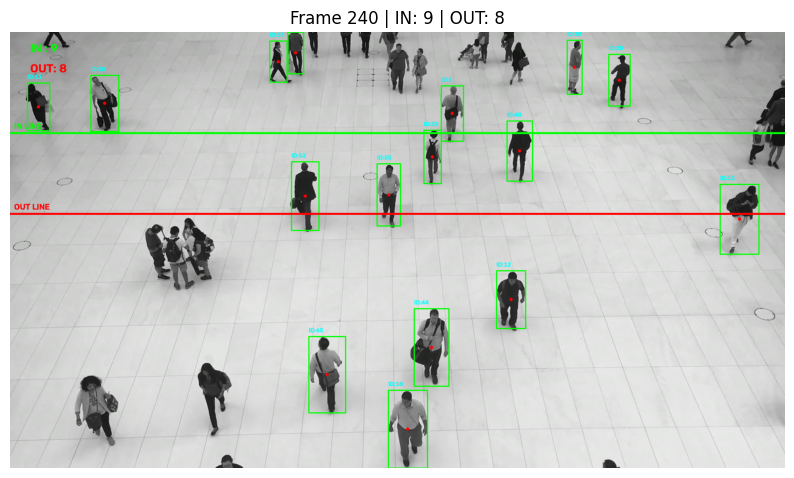

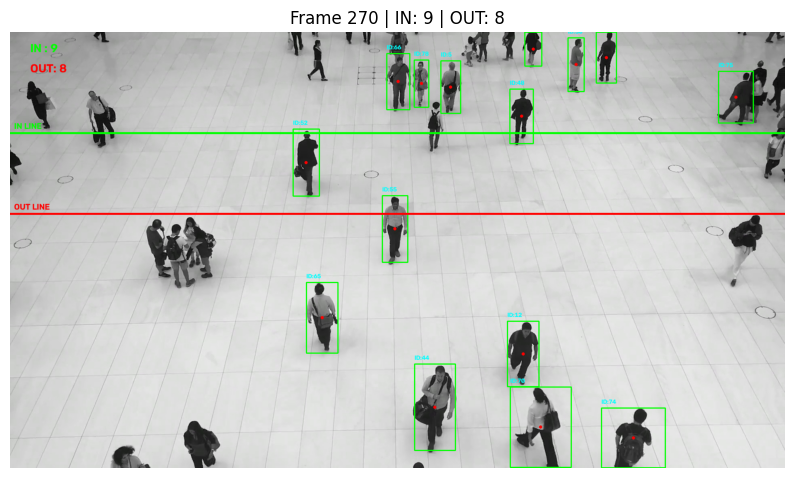

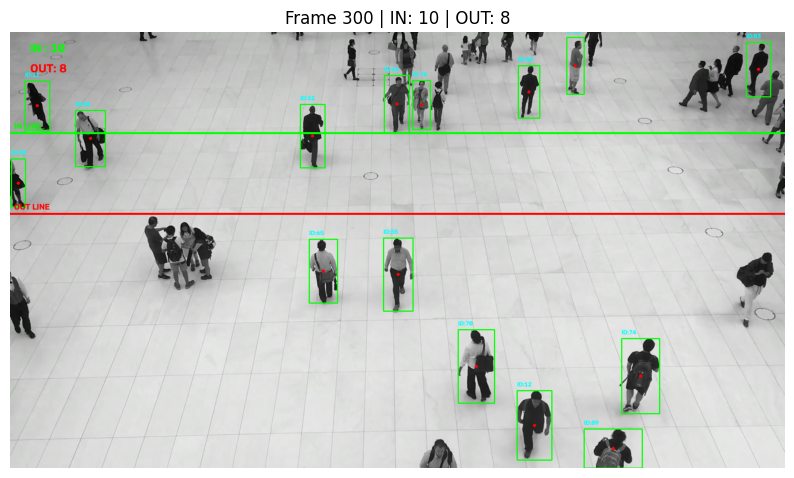

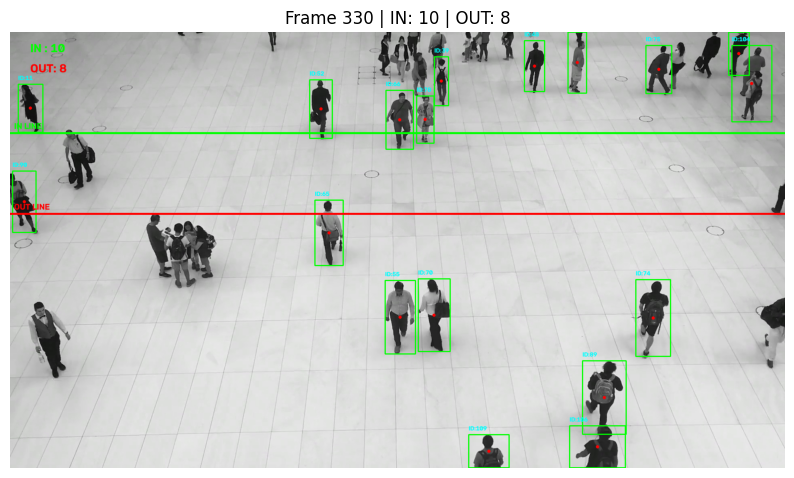


Video processing completed successfully!
Total IN : 10
Total OUT: 8
Output video saved as: output_people_flow.mp4

SUMMARY
Total Frames Processed : 341
Total IN  : 10
Total OUT : 8
Unique IDs Tracked     : 77
Heatmap Data Collected : Yes
Output Video   : Yes
Tracker Used   : ByteTrack (bytetrack.yaml)


In [7]:
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % CONFIG['frame_skip'] != 0:
        continue

    # 1. Detection + Tracking using ByteTrack
    results = model.track(
        frame,
        persist=True,
        tracker='bytetrack.yaml',
        classes=[0],
        conf=CONFIG['conf_threshold'],
        verbose=False
    )

    # 2. Extract bounding boxes and track IDs
    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)
        track_ids = results[0].boxes.id.cpu().numpy().astype(int)
    else:
        boxes = []
        track_ids = []

    # 3. Loop through each detected and tracked person
    for box, track_id in zip(boxes, track_ids):
        x1, y1, x2, y2 = box
        centroid_x = int((x1 + x2) / 2)
        centroid_y = int((y1 + y2) / 2)

        # IN/OUT Counting Logic (Double-Count Protected)
        if track_id in previous_positions:
            prev_y = previous_positions[track_id]

            # IN: Crosses the upper line moving downward
            if prev_y < CONFIG['line_in_y'] and centroid_y >= CONFIG['line_in_y']:
                if track_id not in crossed_in:
                    in_count += 1
                    crossed_in.add(track_id)
                    if track_id in crossed_out:
                        crossed_out.remove(track_id)

            # OUT: Crosses the lower line moving upward
            if prev_y > CONFIG['line_out_y'] and centroid_y <= CONFIG['line_out_y']:
                if track_id not in crossed_out:
                    out_count += 1
                    crossed_out.add(track_id)
                    if track_id in crossed_in:
                        crossed_in.remove(track_id)

        # Update dictionary with the current Y position
        previous_positions[track_id] = centroid_y

        # Draw Bounding Box and ID
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.circle(frame, (centroid_x, centroid_y), 4, (0, 0, 255), -1)
        cv2.putText(frame, f"ID:{track_id}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)

        # Update Heatmap
        if 0 <= centroid_y < frame_height and 0 <= centroid_x < frame_width:
            heatmap[centroid_y, centroid_x] += 1

    # Draw the Two Virtual Lines
    cv2.line(frame, (0, CONFIG['line_in_y']), (frame_width, CONFIG['line_in_y']), (0, 255, 0), 3)
    cv2.putText(frame, "IN LINE", (10, CONFIG['line_in_y'] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2.line(frame, (0, CONFIG['line_out_y']), (frame_width, CONFIG['line_out_y']), (0, 0, 255), 3)
    cv2.putText(frame, "OUT LINE", (10, CONFIG['line_out_y'] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    # Display Live Counters on Frame
    cv2.putText(frame, f"IN : {in_count}", (50, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
    cv2.putText(frame, f"OUT: {out_count}", (50, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

    # Write frame to output video
    out.write(frame)

    # Show sample frames every 30 frames
    if frame_count % 30 == 0:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(rgb)
        plt.title(f"Frame {frame_count} | IN: {in_count} | OUT: {out_count}")
        plt.axis('off')
        plt.show()

# Release all resources
cap.release()
out.release()

print("\nVideo processing completed successfully!")
print(f"Total IN : {in_count}")
print(f"Total OUT: {out_count}")
print(f"Output video saved as: {CONFIG['output_video']}")

# Professional Summary Output
print("\n" + "="*40)
print("SUMMARY")
print("="*40)
print(f"Total Frames Processed : {frame_count}")
print(f"Total IN  : {in_count}")
print(f"Total OUT : {out_count}")
print(f"Unique IDs Tracked     : {len(previous_positions)}")
print(f"Heatmap Data Collected : Yes")
print(f"Output Video   : Yes")
print(f"Tracker Used   : ByteTrack (bytetrack.yaml)")
print("="*40)

#**Step:8 – Generate Standalone Heatmap**


Raw heatmap max value: 19.0
Blurred heatmap re-normalized. Max value: 255
EXAMPLE 1 - Final heatmap saved as: 'final_heatmap.png'


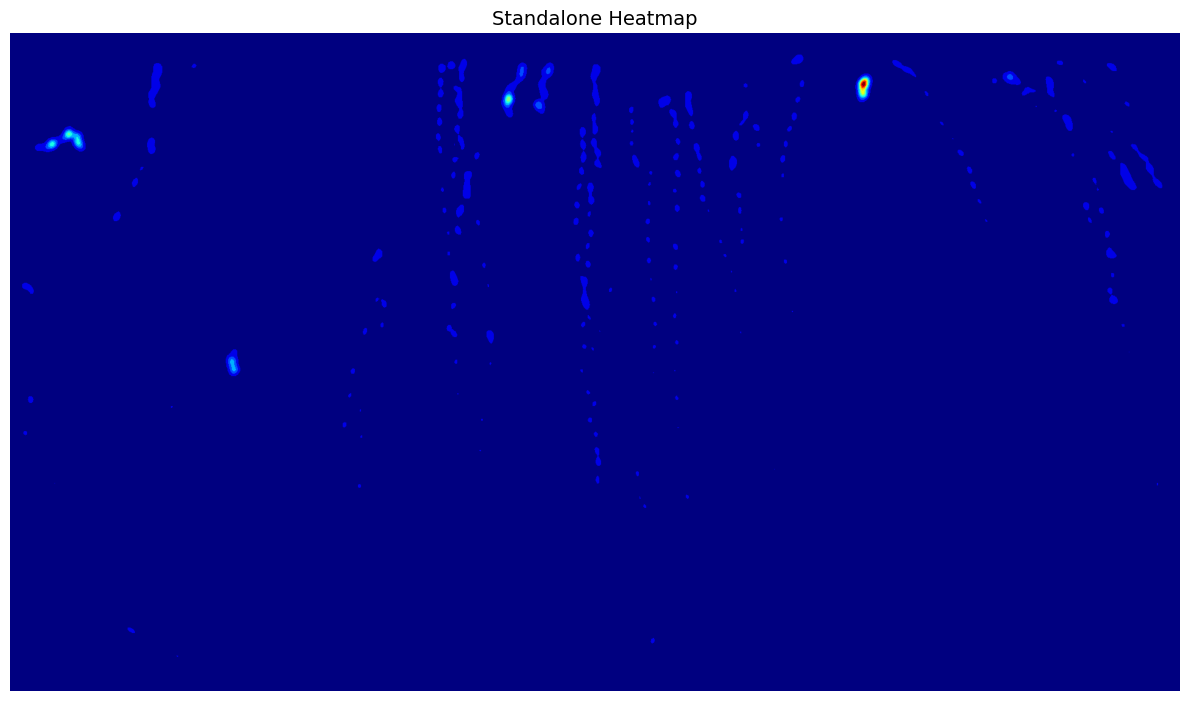

In [8]:
# Standalone Heatmap

if np.max(heatmap) > 0:
    print(f"Raw heatmap max value: {np.max(heatmap)}")

    # Step 1: Normalize raw points to 0-255
    heatmap_norm = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Step 2: Apply Gaussian Blur
    kernel_size = 31
    blurred_heatmap = cv2.GaussianBlur(heatmap_norm, (kernel_size, kernel_size), 0)

    # Step 3: Re-normalize after blur
    if np.max(blurred_heatmap) > 0:
        blurred_heatmap = cv2.normalize(blurred_heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        print(f"Blurred heatmap re-normalized. Max value: {np.max(blurred_heatmap)}")
    else:
        print("Blur reduced everything to zero. Using original normalized data.")
        blurred_heatmap = heatmap_norm

    # Step 4: Apply JET colormap (creates the blue-toned image you want)
    heatmap_colored = cv2.applyColorMap(blurred_heatmap, cv2.COLORMAP_JET)

    # Step 5: Save the final heatmap
    cv2.imwrite('final_heatmap.png', heatmap_colored)
    print("EXAMPLE 1 - Final heatmap saved as: 'final_heatmap.png'")

    # Step 6: Display in Colab
    rgb_heatmap = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(rgb_heatmap)
    plt.title("Standalone Heatmap", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No movement data found. Heatmap is empty.")
    print("This means the main loop did not detect any people.")

#**Step:9 – Generate Overlay Heatmap on Video Frame**

#**Example : Heatmap Overlay on Video Frame**

Raw heatmap max value: 19.0
Blurred heatmap re-normalized. Max value: 255
EXAMPLE 2 - Overlay heatmap saved as: 'heatmap_overlay.png'


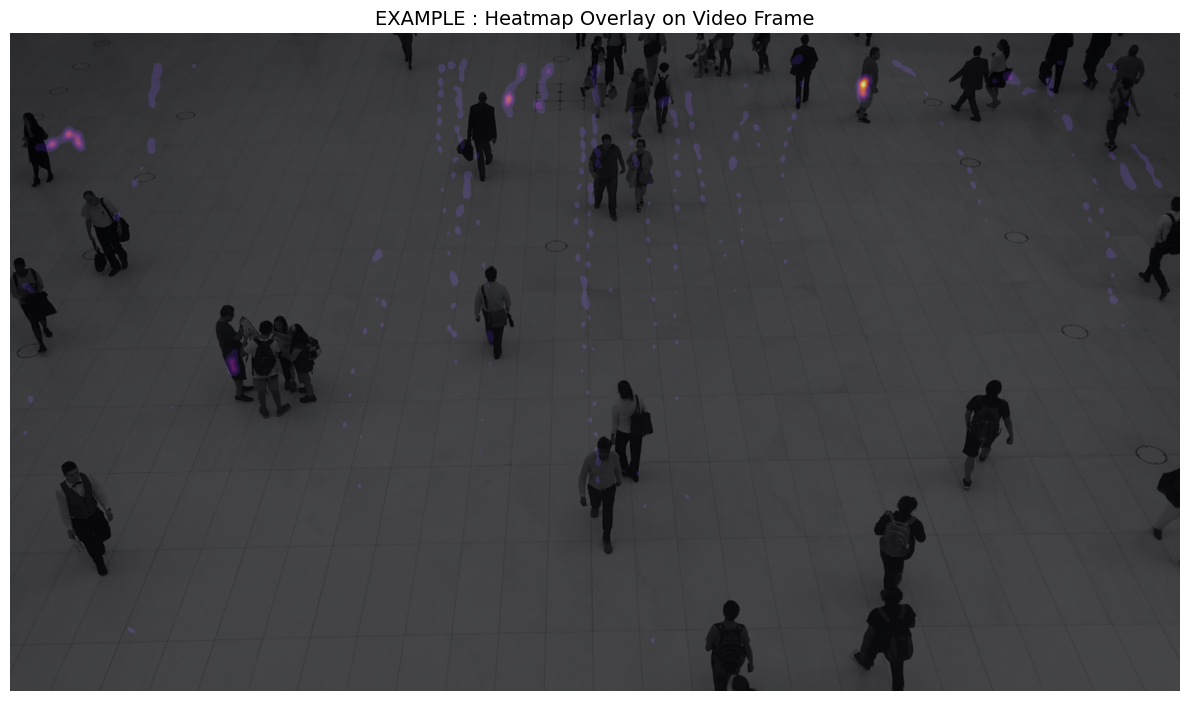

In [9]:
# EXAMPLE : Heatmap Overlay on Video Frame

# Capture the last frame from the video to use as background
cap = cv2.VideoCapture(CONFIG['video_name'])
last_frame = None
while True:
    ret, frame = cap.read()
    if not ret:
        break
    last_frame = frame.copy()
cap.release()

if np.max(heatmap) > 0 and last_frame is not None:
    print(f"Raw heatmap max value: {np.max(heatmap)}")

    # Step 1: Normalize raw points to 0-255
    heatmap_norm = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Step 2: Apply Gaussian Blur
    kernel_size = 31
    blurred_heatmap = cv2.GaussianBlur(heatmap_norm, (kernel_size, kernel_size), 0)

    # Step 3: Re-normalize after blur
    if np.max(blurred_heatmap) > 0:
        blurred_heatmap = cv2.normalize(blurred_heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        print(f"Blurred heatmap re-normalized. Max value: {np.max(blurred_heatmap)}")
    else:
        print("Blur reduced everything to zero. Using original normalized data.")
        blurred_heatmap = heatmap_norm

    # Step 4: Apply colorful colormap (INFERNO for a different look)
    heatmap_colored = cv2.applyColorMap(blurred_heatmap, cv2.COLORMAP_INFERNO)

    # Step 5: Resize heatmap to match the frame dimensions
    if heatmap_colored.shape[:2] != last_frame.shape[:2]:
        heatmap_colored = cv2.resize(heatmap_colored, (last_frame.shape[1], last_frame.shape[0]))

    # Step 6: Combine background with heatmap overlay
    final_heatmap = cv2.addWeighted(last_frame, 0.3, heatmap_colored, 0.7, 0)

    # Step 7: Save the overlaid heatmap
    cv2.imwrite('heatmap_overlay.png', final_heatmap)
    print("EXAMPLE 2 - Overlay heatmap saved as: 'heatmap_overlay.png'")

    # Step 8: Display in Colab
    rgb_heatmap = cv2.cvtColor(final_heatmap, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(rgb_heatmap)
    plt.title("EXAMPLE : Heatmap Overlay on Video Frame", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    if np.max(heatmap) == 0:
        print("No movement data found. Heatmap is empty.")
    else:
        print("No background frame available. Saving standalone heatmap instead.")
        # Fallback: Save standalone heatmap
        heatmap_norm = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        blurred_heatmap = cv2.GaussianBlur(heatmap_norm, (31, 31), 0)
        if np.max(blurred_heatmap) > 0:
            blurred_heatmap = cv2.normalize(blurred_heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        heatmap_colored = cv2.applyColorMap(blurred_heatmap, cv2.COLORMAP_INFERNO)
        cv2.imwrite('heatmap_overlay.png', heatmap_colored)
        print("Fallback: Standalone heatmap saved as 'heatmap_overlay.png'")

#**Step:10 – Generate README.md**

In [10]:
readme_content = """
# People Flow Detection using Object Tracking & Heatmap Visualization
## Module 16 Assignment
**Prepared by:** Farjana Ferdausi

### Detection Method
- **Model:** YOLOv8n (pre-trained on COCO dataset)
- **Tracking:** ByteTrack (explicitly specified using 'bytetrack.yaml')
- **Framework:** Google Colab, OpenCV, Ultralytics

### Line Coordinates
The line coordinates (Y=250 and Y=450) were **determined using the Roboflow PolygonZone web tool** (https://polygonzone.roboflow.com/).
- **IN Line (Upper):** Y = 250 (People moving from top to bottom)
- **OUT Line (Lower):** Y = 450 (People moving from bottom to top)

### IN/OUT Logic Explanation
- **IN (Entry):** The system compares a person's centroid Y-coordinate between consecutive frames. If the centroid moves from **above** the upper line (Y < 250) to **on or below** the upper line (Y >= 250), it is counted as **IN**.
- **OUT (Exit):** If the centroid moves from **below** the lower line (Y > 450) to **on or above** the lower line (Y <= 450), it is counted as **OUT**.
- A Python dictionary (`previous_positions`) stores the last known Y-coordinate for each unique Track ID. **Double-counting is prevented** using a state-tracking mechanism (`crossed_in` / `crossed_out` sets) that ensures a single ID is not counted multiple times for oscillating movements around a line.

### Heatmap Visualizations
Two heatmap visualizations are generated:
1. **final_heatmap.png** - Standalone heatmap (JET colormap, blue-toned) showing motion density.
2. **heatmap_overlay.png** - Heatmap overlaid on the video frame (70% heatmap, 30% background) using INFERNO colormap for a vibrant effect.

### Files Generated
- `output_people_flow.mp4` - Annotated video with bounding boxes, unique IDs, live counters, and the two virtual lines.
- `final_heatmap.png` - Standalone heatmap visualization.
- `heatmap_overlay.png` - Heatmap overlay on the video frame.
- `README.md` - This documentation file.

### How to Run
1. Open this notebook in Google Colab.
2. Run all cells sequentially.
3. The video will be downloaded automatically from the provided Roboflow link.
4. The final annotated video and both heatmap visualizations will be generated and saved in the current Colab environment.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md file created successfully!")

README.md file created successfully!


#**Step:11 – Download & Save Output Files**

In [11]:
from google.colab import files
import os

# List of files to download
files_to_download = [
    'output_people_flow.mp4',
    'final_heatmap.png',        # <-- Step 8 output (JET)
    'heatmap_overlay.png',      # <-- Step 9 output (overlay)
    'README.md'
]

for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"Downloading: {file_name}")
        files.download(file_name)
    else:
        print(f"File not found: {file_name}")

print("\nAll available files have been downloaded to your 'Downloads' folder.")

# Save to Google Drive
print("\nAttempting to save to Google Drive...")

!mkdir -p "/content/drive/MyDrive/Module_16_Assignment"

for file_name in files_to_download:
    if os.path.exists(file_name):
        !cp {file_name} "/content/drive/MyDrive/Module_16_Assignment/"
        print(f"Copied {file_name} to Google Drive > My Drive > Module_16_Assignment")
    else:
        print(f"{file_name} not found in Colab.")

print("\nAll available files copied to your Google Drive!")
print("Check: drive.google.com > My Drive > Module_16_Assignment")

Downloading: output_people_flow.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: final_heatmap.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: README.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All available files have been downloaded to your 'Downloads' folder.

Attempting to save to Google Drive...
Copied output_people_flow.mp4 to Google Drive > My Drive > Module_16_Assignment
Copied final_heatmap.png to Google Drive > My Drive > Module_16_Assignment
Copied heatmap_overlay.png to Google Drive > My Drive > Module_16_Assignment
Copied README.md to Google Drive > My Drive > Module_16_Assignment

All available files copied to your Google Drive!
Check: drive.google.com > My Drive > Module_16_Assignment
